# Markowitz Python

In [37]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import pandas as pd
from scipy.optimize import minimize
import matplotlib.ticker as mtick

In [39]:
inicio = dt.date(2015, 1, 1)
final = dt.date(2024, 12, 31)

In [40]:
#lista_acoes = ["WEGE3", "LREN3", "VALE3", "PETR4", "EQTL3", "EGIE3"]
#lista_acoes = [acao + ".SA" for acao in lista_acoes]
lista_acoes = ["BERK34.SA", "COCA34.SA", "VT", "AMZO34.SA"]

precos = yf.download(lista_acoes, inicio, final)['Close']
precos

[*********************100%***********************]  4 of 4 completed


Ticker,AMZO34.SA,BERK34.SA,COCA34.SA,VT
Date,,,,
2015-01-02,2.087300,20.100000,14.100810,47.904362
2015-01-05,2.060750,20.200001,14.517730,46.977589
2015-01-06,1.981200,20.200001,14.517730,46.506214
2015-01-07,2.018400,19.950001,15.471062,47.105419
2015-01-08,2.017850,20.131001,14.604856,47.816471
...,...,...,...,...
2024-12-23,69.800003,140.899994,64.032143,118.373344
2024-12-24,NaN,NaN,NaN,119.310280
2024-12-26,70.400002,142.179993,63.952717,119.449821


In [41]:
retornos = precos.pct_change().apply(lambda x: np.log(1+x)).dropna() #retorno logaritmo
media_retornos = retornos.mean()
matriz_cov = retornos.cov() 

media_retornos

C:\Users\luiz-\AppData\Local\Temp\ipykernel_5440\1790380381.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos = precos.pct_change().apply(lambda x: np.log(1+x)).dropna() #retorno logaritmo


Ticker
AMZO34.SA    0.001358
BERK34.SA    0.000754
COCA34.SA    0.000581
VT           0.000348
dtype: float64

In [42]:
matriz_cov

Ticker,AMZO34.SA,BERK34.SA,COCA34.SA,VT
Ticker,,,,
AMZO34.SA,0.000456,0.000089,0.000057,0.000061
BERK34.SA,0.000089,0.000189,0.000073,0.000034
COCA34.SA,0.000057,0.000073,0.000174,0.000013
VT,0.000061,0.000034,0.000013,0.000115


In [43]:
numero_carteiras = 100000
vetor_retornos_esperados = np.zeros(numero_carteiras)
vetor_volatilidades_esperadas = np.zeros(numero_carteiras)
vetor_sharpe = np.zeros(numero_carteiras)
tabela_pesos = np.zeros((numero_carteiras, len(lista_acoes)))

for k in range(numero_carteiras):
    
    pesos = np.random.random(len(lista_acoes))
    pesos = pesos/np.sum(pesos) #só pode ter 100% 
    tabela_pesos[k, :] = pesos
    
    vetor_retornos_esperados[k] = np.sum(media_retornos * pesos * 252)
    vetor_volatilidades_esperadas[k] = np.sqrt(np.dot(pesos.T, np.dot(matriz_cov*252, pesos)))
    
    vetor_sharpe[k] = vetor_retornos_esperados[k]/vetor_volatilidades_esperadas[k]

In [44]:
vetor_sharpe

array([1.07243952, 1.08767785, 1.1699754 , ..., 1.16168563, 1.10212351,
       1.19877625])

In [45]:
indice_do_sharpe_maximo = vetor_sharpe.argmax()
tabela_pesos[indice_do_sharpe_maximo]

array([0.31841826, 0.29799833, 0.23833671, 0.1452467 ])

In [46]:
tabela_retornos_esperados_arit = np.exp(vetor_retornos_esperados) - 1

tabela_retornos_esperados_arit

array([0.17422631, 0.16664965, 0.18731642, ..., 0.24855312, 0.18113641,
       0.26587744])

In [47]:
eixo_y_fronteira_eficiente = np.linspace(tabela_retornos_esperados_arit.min(), 
                                         tabela_retornos_esperados_arit.max(), 50)

def pegando_retorno(peso_teste):
    peso_teste = np.array(peso_teste)
    retorno = np.sum(media_retornos * peso_teste) * 252
    retorno = np.exp(retorno) - 1

    return retorno

def checando_soma_pesos(peso_teste):

    return np.sum(peso_teste)-1

def pegando_vol(peso_teste):
    peso_teste = np.array(peso_teste)
    vol = np.sqrt(np.dot(peso_teste.T, np.dot(matriz_cov*252, peso_teste)))
    
    return vol

peso_inicial = [1/len(lista_acoes)] * len(lista_acoes) 

limites = tuple([(0, 1) for ativo in lista_acoes])

eixo_x_fronteira_eficiente = []

for retorno_possivel in eixo_y_fronteira_eficiente:
    
    #vamos pegar a melhor volatilidade para cada retorno possível
    
    restricoes = ({'type':'eq', 'fun':checando_soma_pesos},
            {'type':'eq', 'fun': lambda w: pegando_retorno(w) - retorno_possivel})
    
    result = minimize(pegando_vol, peso_inicial, method='SLSQP', bounds=limites, 
                      constraints = restricoes)
    eixo_x_fronteira_eficiente.append(result['fun'])

In [48]:
result

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.32467741637300895
       x: [ 9.463e-01  5.369e-02  0.000e+00  3.036e-18]
     nit: 4
     jac: [ 3.389e-01  7.340e-02  4.461e-02  4.655e-02]
    nfev: 20
    njev: 4

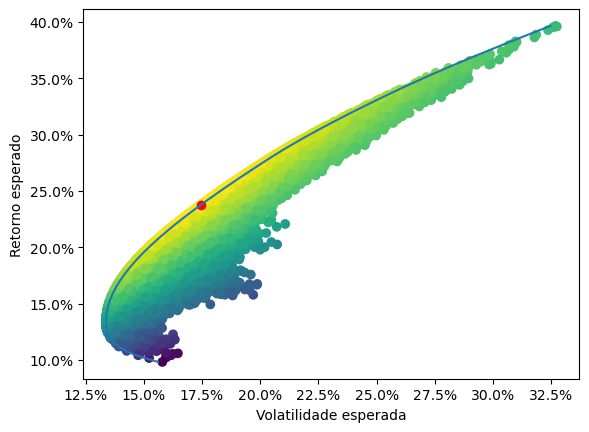

In [49]:
fig, ax = plt.subplots()

ax.scatter(vetor_volatilidades_esperadas, tabela_retornos_esperados_arit, c = vetor_sharpe)
plt.xlabel("Volatilidade esperada")
plt.ylabel("Retorno esperado")
ax.scatter(vetor_volatilidades_esperadas[indice_do_sharpe_maximo], 
            tabela_retornos_esperados_arit[indice_do_sharpe_maximo], c = "red")
ax.plot(eixo_x_fronteira_eficiente, eixo_y_fronteira_eficiente)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()